# Rotation response with signal injection — deployment 4, 2025-07-19

Companion to `beam_modulation/beam_modulation.ipynb`, which makes the same figure from the
2026-07-17 motor raster in deployment 5. This one uses **deployment 4** (2025-07-15..20,
Utah), where the platform also turned but almost nothing recorded that it did.

## Setup

The platform turns for a few minutes at a time, roughly once an hour, for several hours a
day. The figure uses one turn from the episode at **2025-07-20 01:11–01:28 UTC** — local
07-19 18:15, the evening of the day before the deployment ended. The notebook reads a
sidecar cache of that window; if the cache is absent it rebuilds it from the raw files on
the external disk, so the only input is `corr_20250719_18*.h5`. Within the extracted
34-minute window the platform is parked for the first ~10 min, turns for ~15 min, and is
parked again for the last ~8 min, which makes the parked stretches a free control on the
same receiver.

Three receivers ran. Which one moved is established from the data, not the header:

| key | behaviour over one turn | role |
|---|---|---|
| 2 | tones swing 5.6–25.7 dB | the receiver on the turning platform |
| 3 | 1.11 dB | stationary control |
| 4 | 0.31 dB | stationary control |

A **comb** sits on every 16th channel (3.906 MHz spacing). It is radiated, not conducted:
switched onto the antenna the tones stand 16.6 dB above the local continuum, switched onto
the load 0.0 dB and onto the noise diode 0.9 dB. It reaches the receiver through the
antenna, which is what makes it usable as an injected signal.

## What the figure shows

One full turn. Each curve is one comb tone, coloured by frequency, referenced to its own
value at the response maximum. The response varies by up to 25.7 dB through the turn.

## Things that are easy to get wrong

- **The comb sits on channel residue 0** (`ch % 16 == 0`), not residue 8 as in deployment 5.
  It stands 13.8 dB above the neighbouring channels in the median. Masking the deployment-5
  residues leaves every tone inside a nominally clean band.
- **There is no rotation telemetry at all.** `metadata/motor` reads `az_pos = el_pos = 0`
  for the entire deployment with its timestamp frozen at 2025-07-11, and
  `metadata/imu_antenna` froze on 07-18 with yaw pinned at $-155^\circ$. `metadata/imu_panda`
  is the worst trap of the three: through this window its timestamps stay fresh, 9 s behind
  the integrations, so it looks alive — but it returns one single frozen quaternion
  (yaw $87.6^\circ$) for all 34 minutes, turning and parked alike. Check the values, not the
  timestamps. `metadata/rfswitch` is the only per-integration metadata that actually updates.
  The turning windows in this notebook were found by searching the radio data for smooth,
  deep, periodic modulation of the comb tones.
- **The x axis cannot honestly be degrees.** Under a uniform-rate rotation the $\pm180^\circ$
  points are the same orientation, so the response there must match. Mapping time to angle at
  a uniform rate puts them 7.2 dB apart on the turn shown and 5.4 dB apart on the next usable
  turn — same sign, same size, so it is reproducible structure rather than noise. The motion
  is periodic at 71 s but it is not a uniform turn, so the figure uses **time through the
  turn** and leaves the kinematics open.
- **`header/rf_chain` is not trustworthy here.** It calls keys 2 and 3 the N and E pols of
  the same vivaldi, but key 2 swings 25.7 dB while key 3 holds to 1.11 dB over the same
  integrations. One antenna cannot do both. Identify receivers by what they do — which is the
  same test `deployment4/noise_dropouts_selfRFI.ipynb` (on the `selfrfi-notebooks` branch)
  used to pick out the rotator-mounted antenna: the comb swings on the one that moves and
  holds flat on the ones that do not.
- **Raw channel power is tone + sky continuum**, so the depth a channel can show is capped by
  how far the tone sits above the continuum. That ratio rises from 6.6 dB at 51 MHz to
  24.6 dB at 199 MHz, and the deepest curves in the figure are the high-frequency ones. The
  frequency ordering is therefore **the link budget, not the beam sharpening**.
- **Do not fold turns together.** Folding the whole ~15-minute episode on its best-fit
  period leaves each turn 2.4–4.2 dB rms from the mean profile. One turn is both cleaner and
  honest about what was measured.
- **Filenames are local and run 6.93 h behind the header times**, which are UTC and correct
  (they agree with `header/upload_time`). The files behind this figure are named
  `corr_20250719_18*` and hold data from 2025-07-20 01:xx UTC.

In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.ndimage import median_filter, uniform_filter1d

OUTDIR = Path.cwd().resolve()
while not (OUTDIR / "build_nb.py").exists():
    if OUTDIR.parent == OUTDIR:
        raise FileNotFoundError("build_nb.py not found above cwd")
    OUTDIR = OUTDIR.parent
SIDECAR = OUTDIR / "rotation_20250720_0101.h5"

# the sidecar is a cache, not tracked; rebuilt from the raw files if it is missing
RAW = Path("/media/christian/Samsung_T5/eigsep_data/deployment4/corr_data")
FILES = [f"corr_20250719_18{s}.h5" for s in
         ("0532", "0950", "1408", "1826", "2244", "2702", "3120", "3539")]

ROT, CTRL = "2", ("3", "4")   # rotating receiver, stationary controls
COMB_RESIDUE = 0              # comb tones sit on ch % 16 == 0
COMB_SPILL = (15, 0, 1)       # tones and their +-1 spillover
FM_BAND = (86.0, 110.0)       # broadcast FM, excluded throughout
MIN_TONE_SNR = 3.0            # dB the tone must exceed the local continuum
MAX_ROUGHNESS = 0.05          # dB, point-to-point roughness of the flanking channels
FLAG_DB = 3.0                 # deviation from a 5-sample rolling median that flags a sample

In [2]:
keys = (ROT,) + CTRL


def build_sidecar():
    # Pull the window off the raw files.  Of the per-integration metadata only
    # metadata/rfswitch is alive in deployment 4, so that is all we carry over.
    import json
    times, states, blocks = [], [], {k: [] for k in keys}
    for name in FILES:
        with h5py.File(RAW / name, "r") as f:
            tt = np.asarray(json.loads(f["header/times"][()].decode()), float)
            ss = np.array([m.get("sw_state", -1)
                           for m in json.loads(f["metadata/rfswitch"][()].decode())])
            cols = {k: f[f"data/{k}"][:] for k in keys}
            dfreq, nch = f["header"].attrs["dfreq"], f["header"].attrs["nchan"]
        n = min(len(tt), len(ss), *(c.shape[0] for c in cols.values()))
        times.append(tt[:n]); states.append(ss[:n])
        for k in keys:
            blocks[k].append(cols[k][:n].astype(np.float32))
    with h5py.File(SIDECAR, "w") as f:
        f.attrs["files"] = ",".join(FILES)
        f["times"] = np.concatenate(times)
        f["sw_state"] = np.concatenate(states)
        f["freqs"] = np.arange(nch) * dfreq
        for k in keys:
            f.create_dataset(f"data/{k}", data=np.concatenate(blocks[k]),
                             compression="gzip", compression_opts=4)


if not SIDECAR.exists():
    print(f"building {SIDECAR.name} from {RAW}")
    build_sidecar()

with h5py.File(SIDECAR, "r") as f:
    d = {k: f[f"data/{k}"][:].astype(np.float64) for k in keys}
    t = f["times"][:]
    sw = f["sw_state"][:]
    freq = f["freqs"][:]            # MHz, 0.244140625 spacing
for k in d:
    d[k][d[k] <= 0] = np.nan

# a handful of integrations come back empty in every receiver; drop them so they cannot
# turn into all-NaN medians further down
live = ~np.isnan(d[ROT]).all(1)
print(f"{(~live).sum()} empty integrations dropped")
d = {k: v[live] for k, v in d.items()}
t, sw = t[live], sw[live]

nchan = freq.size
chan = np.arange(nchan)
tsec = t - t[0]
sky = sw == 0                       # the antenna path; everything else is load or noise diode

print(f"{len(t)} integrations x {nchan} channels, {tsec[-1] / 60:.1f} min contiguous")
print(f"{sky.sum()} on the antenna, {len(t) - sky.sum()} on load / noise diode")


def to_db(x):
    with np.errstate(divide="ignore", invalid="ignore"):
        return 10.0 * np.log10(x)


def flanking(c, half=(3, 7)):
    # non-comb channels either side of tone channel c, clear of its spillover
    lo, hi = half
    offs = [o for o in range(-hi + 1, hi) if lo <= abs(o) < hi]
    return [c + o for o in offs if 0 <= c + o < nchan and (c + o) % 16 not in COMB_SPILL]

3 empty integrations dropped
1914 integrations x 1024 channels, 34.4 min contiguous
1842 on the antenna, 72 on load / noise diode


### The comb reaches the receiver through the antenna

Worth settling before anything else: a comb every 16 channels could be radiated and picked up
by the antenna, or it could be conducted into the receiver, in which case it would carry no
information about where the antenna points. The switch cycle answers it — the tones survive
only on the antenna path.

In [3]:
band = (freq > 150) & (freq < 195)
tone_m = (chan % 16 == COMB_RESIDUE) & band
cont_m = ~np.isin(chan % 16, COMB_SPILL) & band
contrast = to_db(np.nanmedian(d[ROT][:, tone_m], 1)) - to_db(np.nanmedian(d[ROT][:, cont_m], 1))

for state, n in zip(*np.unique(sw, return_counts=True)):
    if n < 5:
        continue
    m = sw == state
    print(f"sw_state {state:3d} ({n:4d} ints): continuum "
          f"{np.nanmedian(to_db(np.nanmedian(d[ROT][m][:, cont_m], 1))):5.1f} dB, "
          f"comb {np.nanmedian(contrast[m]):5.1f} dB above it")

sw_state   0 (1842 ints): continuum  60.3 dB, comb  16.6 dB above it
sw_state   1 (  11 ints): continuum  61.3 dB, comb  16.4 dB above it
sw_state   3 (  11 ints): continuum  61.3 dB, comb  16.4 dB above it
sw_state   4 (  11 ints): continuum  61.3 dB, comb  16.4 dB above it
sw_state  24 (  12 ints): continuum  73.8 dB, comb   0.9 dB above it
sw_state 160 (  12 ints): continuum  60.2 dB, comb  -0.0 dB above it
sw_state 224 (  11 ints): continuum  60.2 dB, comb  -0.0 dB above it


### Finding the turn

With no encoder, the turning stretch is located by the modulation itself: a rolling
peak-to-peak of the comb contrast separates turning from parked. Inside it, the response
maxima mark the turns. The two maxima in each turn differ by about 6 dB, which is only
possible if they are half a turn apart on a beam with different fore and aft response — so
successive *tall* maxima bound one full turn.

In [4]:
c = np.where(sky, contrast, np.nan)
W = 70
pp = np.full(len(c), np.nan)
for i in range(len(c) - W):
    v = c[i:i + W]
    if np.isfinite(v).sum() > 0.8 * W:
        pp[i] = np.nanmax(v) - np.nanmin(v)
turning = np.where(pp > 8)[0]
T0, T1 = tsec[turning[0]], tsec[turning[-1] + W]
print(f"platform turning from t = {T0:.0f} s to {T1:.0f} s ({(T1 - T0) / 60:.1f} min); "
      f"parked before and after")

k = (tsec > T0) & (tsec < T1) & np.isfinite(c)
x, ys = tsec[k], uniform_filter1d(c[k], 5)
peaks = [i for i in range(3, len(ys) - 3) if ys[i] == max(ys[i - 3:i + 4]) and ys[i] > 18.0]
tall = []
for i in peaks:
    if not tall or x[i] - x[tall[-1]] > 20:
        tall.append(i)
    elif ys[i] > ys[tall[-1]]:
        tall[-1] = i
tm = x[tall]
print(f"{len(tm)} tall maxima; intervals [s]: {np.round(np.diff(tm), 1)}")

# a usable turn needs a tall maximum one turn either side of it
usable = [n for n in range(1, len(tm) - 1)
          if 60 < tm[n] - tm[n - 1] < 95 and 60 < tm[n + 1] - tm[n] < 95]
A, B, E = tm[usable[0] - 1], tm[usable[0]], tm[usable[0] + 1]
HALF = 0.25 * (B - A) + 0.25 * (E - B)
sel = sky & (np.abs(tsec - B) <= HALF)
tau = tsec - B
print(f"showing the turn centred at t = {B:.1f} s: {2 * HALF:.1f} s, {sel.sum()} integrations")

platform turning from t = 586 s to 1588 s (16.7 min); parked before and after
13 tall maxima; intervals [s]: [150.3  42.9  70.9  71.9 117.   42.9  33.3  40.8  69.8  73.  138.5  31.1]
showing the turn centred at t = 940.6 s: 71.4 s, 67 integrations


### Why the x axis is time and not degrees

Under a uniform-rate turn, $-180^\circ$ and $+180^\circ$ are the same orientation, so the
response there has to match. It does not, on either usable turn, by the same sign and a
similar amount — so the discrepancy is structure, not noise, and a degree axis built on a
uniform rate would put real features at the wrong angles.

In [5]:
for n in usable:
    a, b, e = tm[n - 1], tm[n], tm[n + 1]
    lo, hi = a + 0.5 * (b - a), b + 0.5 * (e - b)
    r0 = np.nanmedian(c[sky & (np.abs(tsec - lo) < 3.0)])
    r1 = np.nanmedian(c[sky & (np.abs(tsec - hi) < 3.0)])
    print(f"turn at t = {b:6.1f} s:  R(-180 deg) = {r0:5.1f} dB, R(+180 deg) = {r1:5.1f} dB"
          f"   -> mismatch {r0 - r1:+5.1f} dB")

turn at t =  940.6 s:  R(-180 deg) =  17.9 dB, R(+180 deg) =  10.7 dB   -> mismatch  +7.2 dB
turn at t = 1316.4 s:  R(-180 deg) =  15.7 dB, R(+180 deg) =  10.3 dB   -> mismatch  +5.4 dB


### Selecting tones

A tone is used only if it is **clean** (its flanking channels are not RFI-ridden) and
**dominant** (it exceeds the local continuum by `MIN_TONE_SNR`). The census runs on the
parked lead-in, so nothing about the turn can bias it.

In [6]:
lead = sky & (tsec < T0 - 40.0)
spec = to_db(np.nanmedian(d[ROT][lead], 0))
excess = [np.nanmedian(spec[(chan % 16 == r) & (freq > 50) & (freq < 200)]) for r in range(16)]
print(f"comb residue {COMB_RESIDUE} stands {excess[COMB_RESIDUE] - np.median(excess):.1f} dB "
      f"above the other residues")

tones, rejected = [], []
for c_ in chan[chan % 16 == COMB_RESIDUE]:
    if not 50.0 < freq[c_] < 200.0:
        continue
    if FM_BAND[0] < freq[c_] < FM_BAND[1]:
        rejected.append((freq[c_], "FM band")); continue
    nb = flanking(c_)
    snr = spec[c_] - np.nanmedian(spec[nb])
    rough = np.nanmedian(np.abs(np.diff(to_db(np.nanmedian(d[ROT][lead][:, nb], 1)), 2)))
    if rough >= MAX_ROUGHNESS:
        rejected.append((freq[c_], f"RFI, roughness {rough:.3f} dB")); continue
    if snr < MIN_TONE_SNR:
        rejected.append((freq[c_], f"tone only {snr:.1f} dB over continuum")); continue
    tones.append(c_)

tone_freq = freq[np.array(tones)]
print(f"{len(tones)} tones kept, {tone_freq.min():.1f}-{tone_freq.max():.1f} MHz, "
      f"spacing {16 * (freq[1] - freq[0]):.3f} MHz")
print(f"tone above continuum: {spec[tones[0]] - np.nanmedian(spec[flanking(tones[0])]):.1f} dB at "
      f"{tone_freq[0]:.0f} MHz rising to "
      f"{spec[tones[-1]] - np.nanmedian(spec[flanking(tones[-1])]):.1f} dB at {tone_freq[-1]:.0f} MHz")
print(f"{len(rejected)} rejected:")
for f_, why in rejected:
    print(f"    {f_:7.1f} MHz  {why}")

comb residue 0 stands 13.8 dB above the other residues
32 tones kept, 50.8-199.2 MHz, spacing 3.906 MHz
tone above continuum: 6.6 dB at 51 MHz rising to 24.6 dB at 199 MHz
7 rejected:
       54.7 MHz  tone only 2.2 dB over continuum
       89.8 MHz  FM band
       93.8 MHz  FM band
       97.7 MHz  FM band
      101.6 MHz  FM band
      105.5 MHz  FM band
      109.4 MHz  FM band


### Binning and flagging

At 1.07 s per integration one turn holds 67 samples, about one every $5^\circ$ of turn, so
the curves are drawn from the samples themselves rather than binned. Samples deviating more
than `FLAG_DB` from a 5-sample rolling median are dropped; this removes isolated RFI hits
without smoothing real structure. Each curve is referenced to its own value at the response
maximum, a physical orientation rather than an arbitrary average.

In [7]:
def curve(series):
    s = np.where(sel, series, np.nan)
    smooth = median_filter(np.nan_to_num(s, nan=np.nanmedian(s[sel])), size=5, mode="nearest")
    flagged = np.abs(s - smooth) > FLAG_DB
    s = np.where(flagged, np.nan, s)
    return s[sel] - np.nanmedian(s[sel & (np.abs(tau) < 2.0)]), int(flagged[sel].sum())


prof, nflag = {}, 0
for c_ in tones:
    prof[c_], n = curve(to_db(d[ROT][:, c_]))
    nflag += n
depth = lambda p: np.nanmax(p) - np.nanmin(p)
tone_depths = np.array([depth(prof[c_]) for c_ in tones])
print(f"{nflag} samples flagged out of {sel.sum() * len(tones)}")
print(f"depth over the turn: {tone_depths.min():.1f}-{tone_depths.max():.1f} dB "
      f"(median {np.median(tone_depths):.1f})")

3 samples flagged out of 2144
depth over the turn: 5.6-25.7 dB (median 15.7)


### Controls

Four checks before plotting, all on the same integrations as the figure:

1. **The two stationary receivers on the same tones** — bounds comb drift and common-mode gain.
2. **Non-comb channels on the turning receiver** — the sky continuum, which should show the
   same broad structure far more weakly, since an extended source cannot be nulled the way a
   point source can.
3. **The turning receiver while parked**, immediately before and after the turn — the same
   receiver, same tones, same hour, not moving. Deployment 5 had no equivalent. The first
   minute of the window is a settling transient (the opening integration sits 2 dB low) and is
   excluded; the rest of the parked stretch drifts by 0.00 dB end to end.

In [8]:
for k in CTRL:
    print(f"stationary key {k}, same tones      : "
          f"{depth(curve(to_db(np.nanmedian(d[k][:, tones], 1)))[0]):.2f} dB")

sky_depths = np.array([depth(curve(to_db(np.nanmedian(d[ROT][:, flanking(c_)], 1)))[0])
                       for c_ in tones])
print(f"turning receiver, non-comb        : median {np.median(sky_depths):.2f} dB "
      f"-> tones are {np.median(tone_depths) / np.median(sky_depths):.0f}x deeper")

for name, lo, hi in [("before", 100.0, T0 - 40.0), ("after", T1 + 40.0, tsec[-1])]:
    m = sky & (tsec > lo) & (tsec < hi)
    s = to_db(np.nanmedian(d[ROT][:, tones], 1))[m][:sel.sum()]
    print(f"turning receiver parked {name:6s}    : {np.nanmax(s) - np.nanmin(s):.2f} dB "
          f"over {len(s)} integrations")

stationary key 3, same tones      : 1.11 dB
stationary key 4, same tones      : 0.31 dB
turning receiver, non-comb        : median 0.89 dB -> tones are 18x deeper
turning receiver parked before    : 0.12 dB over 67 integrations
turning receiver parked after     : 0.24 dB over 67 integrations


## The figure

saved /home/christian/Documents/research/eigsep/data-analysis/notebooks/christian/beam_modulation_d4/beam_modulation_d4.pdf


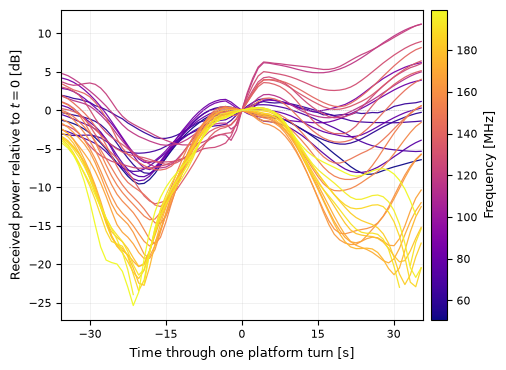

In [9]:
norm = Normalize(tone_freq.min(), tone_freq.max())
smap = ScalarMappable(norm, plt.cm.plasma)

fig, ax = plt.subplots(figsize=(5.2, 3.8))
for c_ in tones:
    ax.plot(tau[sel], prof[c_], color=smap.to_rgba(freq[c_]), lw=0.9, alpha=0.95)

ax.axhline(0.0, color="0.75", lw=0.5, ls=":")
ax.set_xlim(-HALF, HALF)
ax.set_xticks([-30, -15, 0, 15, 30])
ax.grid(alpha=0.25, lw=0.5)
ax.set_xlabel("Time through one platform turn [s]", fontsize=9)
ax.set_ylabel("Received power relative to $t=0$ [dB]", fontsize=9)
ax.tick_params(labelsize=8)

cb = fig.colorbar(smap, ax=ax, pad=0.02)
cb.set_label("Frequency [MHz]", fontsize=9)
cb.ax.tick_params(labelsize=8)

fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(OUTDIR / f"beam_modulation_d4.{ext}", dpi=200, bbox_inches="tight")
print(f"saved {OUTDIR / 'beam_modulation_d4.pdf'}")

## Caption

> Response of the EIGSEP receiver on the turning platform to one full turn, measured against
> a radiated comb. Tones every 3.906 MHz stand above the sky continuum across the band; each
> curve follows one tone through a single turn of the platform, referenced to its value at the
> response maximum. The received power varies by up to 25.7 dB through the turn, with deep
> nulls away from the maximum. Two further receivers, stationary throughout, record the same
> tones over the same integrations and vary by 1.11 and 0.31 dB, and the same turning receiver
> varies by 0.24 dB over an equal stretch while parked minutes later — so the modulation is
> the moving antenna's response and not comb drift or gain variation. The spread between
> curves reflects the comb's efficiency rising with frequency rather than a change in the
> antenna response: raw channel power is the sum of tone and sky continuum, so each channel's
> achievable depth is capped by the tone-to-continuum ratio, which rises from 6.6 dB at 51 MHz
> to 24.6 dB at 199 MHz. The FM broadcast band (86–110 MHz) is excluded. Deployment 4 carried
> no working rotation telemetry, so the abscissa is time through the turn rather than angle.

## Numbers quoted above

| quantity | value |
|---|---|
| episode | 2025-07-20 01:11–01:28 UTC (local 07-19 18:15), ~15 min turning |
| tones used | 32, 50.8–199.2 MHz, 3.906 MHz spacing |
| turn shown | one full turn, 71.4 s, 67 integrations |
| depth, turning receiver | 5.6–25.7 dB (median 15.7 dB) |
| depth, stationary key 3 | 1.11 dB |
| depth, stationary key 4 | 0.31 dB |
| depth, same receiver parked | 0.12 dB before, 0.24 dB after |
| depth, non-comb channels | median 0.89 dB — 18× shallower |
| comb on the antenna / load / noise diode | 16.6 / 0.0 / 0.9 dB above continuum |
| samples flagged | 3 of 2144 |